In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
energy_scaled = scaler.fit_transform(df[['Energy Consumption (kWh)']])

In [ ]:
def create_sequences(data, time_steps=24):
 X, y = [], []
 for i in range(time_steps, len(data)):
  X.append(data[i-time_steps:i, 0])
  y.append(data[i, 0])
 return np.array(X), np.array(y)


In [ ]:
TIME_STEPS = 24
X, y = create_sequences(energy_scaled, TIME_STEPS)

split_index = int(0.8 * len(X))
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [ ]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [ ]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, 1)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
optimizer=Adam(learning_rate=0.001),
loss='mean_squared_error'
)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
X_train,
y_train,
epochs=30,
batch_size=32,
validation_split=0.1,
callbacks=[early_stop],
verbose=1
)

Epoch 1/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 62s 26ms/step - loss: 0.0595 - val_loss: 0.0586
Epoch 2/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 83s 26ms/step - loss: 0.0582 - val_loss: 0.0583
Epoch 3/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 57s 25ms/step - loss: 0.0577 - val_loss: 0.0583
Epoch 4/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - loss: 0.0581 - val_loss: 0.0583
Epoch 5/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 82s 26ms/step - loss: 0.0578 - val_loss: 0.0583
Epoch 6/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 58s 26ms/step - loss: 0.0571 - val_loss: 0.0584
Epoch 7/30
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 56s 25ms/step - loss: 0.0582 - val_loss: 0.0583


In [ ]:
y_pred_scaled = model.predict(X_test)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_actual = scaler.inverse_transform(y_pred_scaled)
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse= np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))

625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step


In [ ]:
print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

LSTM MAE: 0.9018833523416675
LSTM RMSE: 1.1835988135950768


In [ ]:
model.save("lstm_energy_model.h5")

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "LSTM"],
    "MAE": [mae_lr, mae],
    "RMSE": [rmse_lr, rmse]
})

comparison_df


,Model,MAE,RMSE
0,Linear Regression,0.981406,1.222666
1,LSTM,0.901883,1.183599


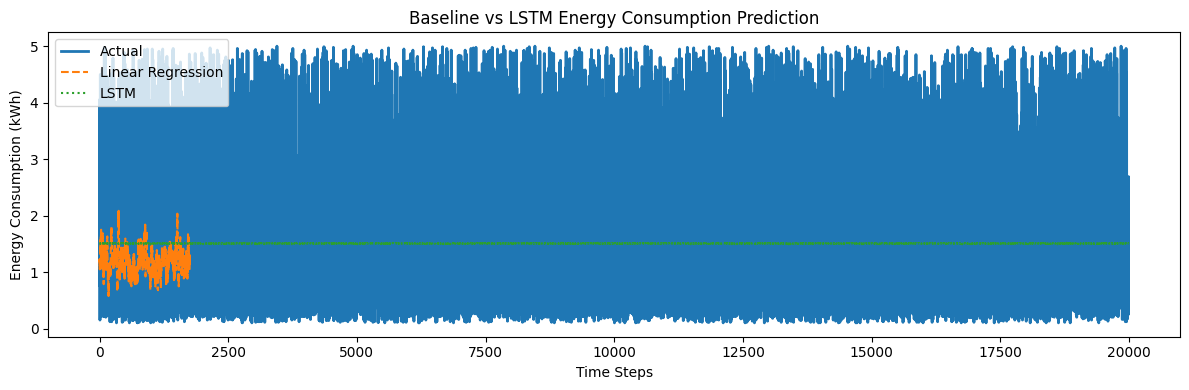

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test_actual, label="Actual", linewidth=2)
plt.plot(y_pred_lr, label="Linear Regression", linestyle="--")
plt.plot(y_pred_actual, label="LSTM", linestyle=":")
plt.title("Baseline vs LSTM Energy Consumption Prediction")
plt.xlabel("Time Steps")
plt.ylabel("Energy Consumption (kWh)")
plt.legend()
plt.tight_layout()
plt.show()
